In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

layers = tf.keras.layers

# ==============================================================================
# 0. CONFIGURAÇÃO DE CAMINHOS E CARREGAMENTO GERAL DA BASE
# ==============================================================================

data_dir = '/content/drive/MyDrive/Mini-Projeto Avaliativo - Módulo 2 - Semana 07/casting_512x512'

# 1. Carregamento da base inteira via TensorFlow/Keras
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 2. Seleção de 1 amostra da base para os testes com OpenCV (Sprints 2 e 3)
# Pega o caminho da primeira imagem da pasta com defeito
pasta_defeito = os.path.join(data_dir, 'def_front')
amostra_nome = os.listdir(pasta_defeito)[0]
caminho_amostra = os.path.join(pasta_defeito, amostra_nome)

Found 1300 files belonging to 2 classes.
Using 1040 files for training.
Found 1300 files belonging to 2 classes.
Using 260 files for validation.


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


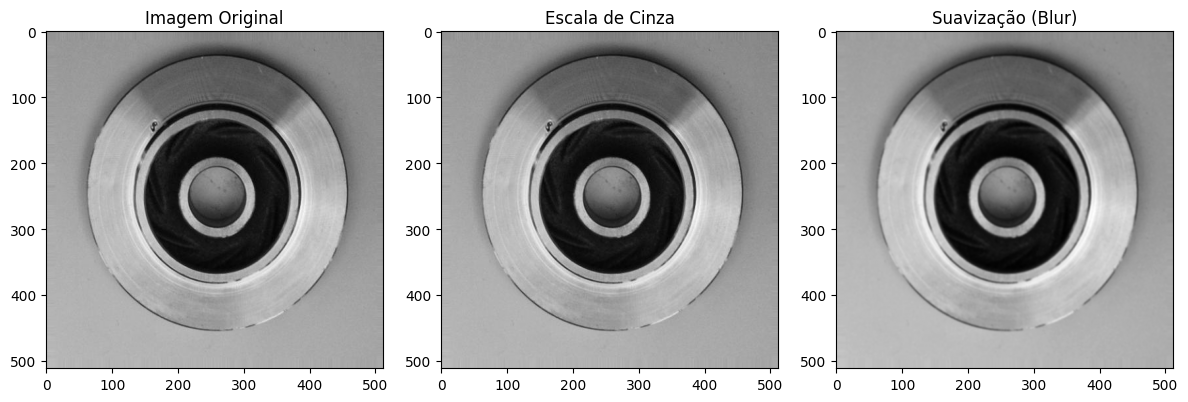

In [11]:
# ==============================================================================
# SPRINT 2: OpenCV - Filtros Básicos na Amostra
# ==============================================================================
img_bgr = cv2.imread(caminho_amostra)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title('Imagem Original')

plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Escala de Cinza')

plt.subplot(1, 3, 3)
plt.imshow(img_blur, cmap='gray')
plt.title('Suavização (Blur)')
plt.tight_layout()
plt.show()

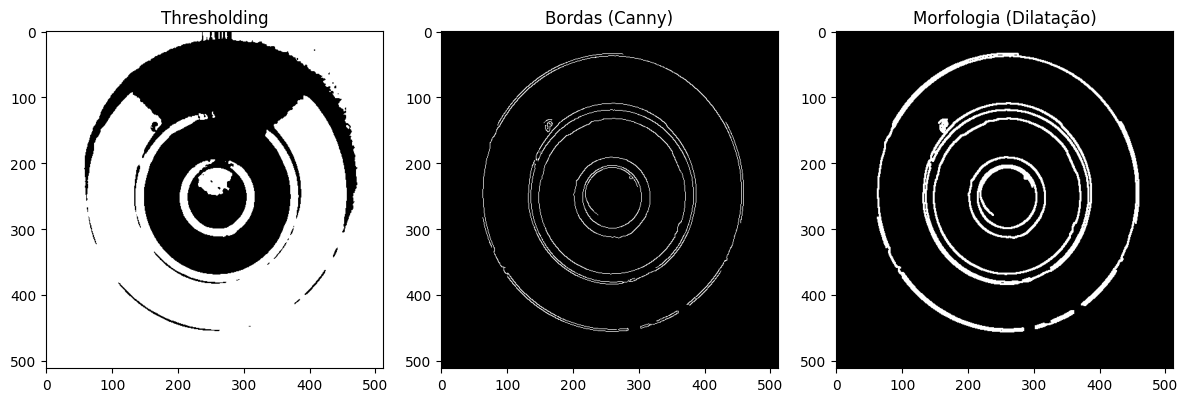

In [12]:
# ==============================================================================
# SPRINT 3: OpenCV - Limiarização, Bordas e Morfologia
# ==============================================================================
_, img_thresh = cv2.threshold(img_blur, 127, 255, cv2.THRESH_BINARY)
img_edges = cv2.Canny(img_blur, 50, 150)
kernel = np.ones((3, 3), np.uint8)
img_dilated = cv2.dilate(img_edges, kernel, iterations=1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_thresh, cmap='gray')
plt.title('Thresholding')

plt.subplot(1, 3, 2)
plt.imshow(img_edges, cmap='gray')
plt.title('Bordas (Canny)')

plt.subplot(1, 3, 3)
plt.imshow(img_dilated, cmap='gray')
plt.title('Morfologia (Dilatação)')
plt.tight_layout()
plt.show()

In [13]:
# ==============================================================================
# SPRINT 4: Data Augmentation
# ==============================================================================
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.2)
], name="data_augmentation")

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.5587 - loss: 0.7278 - val_accuracy: 0.6192 - val_loss: 0.6547
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 31s 698ms/step - accuracy: 0.5962 - loss: 0.6645 - val_accuracy: 0.6192 - val_loss: 0.6390
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 734ms/step - accuracy: 0.5962 - loss: 0.6732 - val_accuracy: 0.6192 - val_loss: 0.6227
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 806ms/step - accuracy: 0.5962 - loss: 0.6414 - val_accuracy: 0.6192 - val_loss: 0.5901
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 843ms/step - accuracy: 0.5962 - loss: 0.6233 - val_accuracy: 0.6192 - val_loss: 0.5536
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 26s 780ms/step - accuracy: 0.5962 - loss: 0.6056 - val_accuracy: 0.6192 - val_loss: 0.5340
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 753ms/step - accuracy: 0.6663 - loss: 0.6054 - val_accuracy: 0.7423 - val_loss: 0.5227
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 776ms/step - accuracy: 0.7077 - loss: 0.5930 - val_accura

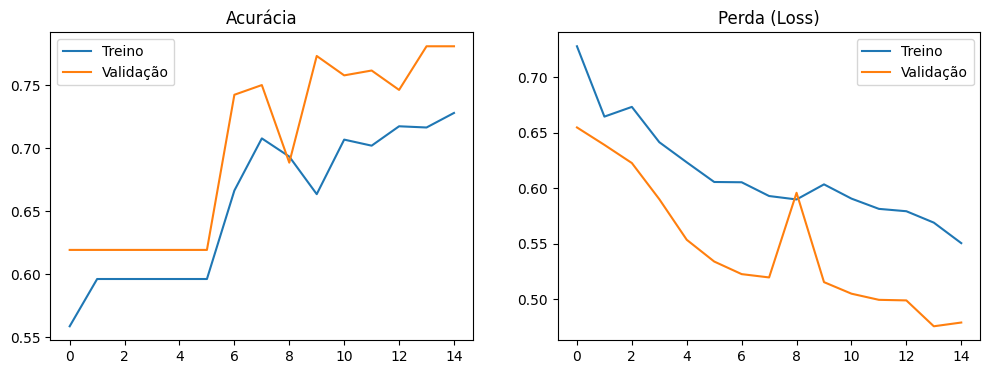

In [14]:
# ==============================================================================
# SPRINT 5 & 6: Construção, Treinamento e Auditoria da CNN
# ==============================================================================
model = tf.keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

EPOCHS = 15
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# Auditoria Gráfica
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Perda (Loss)')
plt.legend()
plt.show()

---

# 🔧 Configuração do GitHub

Nesta etapa será realizada a conexão do notebook com o repositório
GitHub e selecionada a branch `main`.

In [15]:
!git --version

git version 2.43.0


In [16]:
!git config --global user.name "Gustavo Mayer"
!git config --global user.email "gustavomiguelmayer@gmail.com"

In [17]:
!git clone https://github.com/GustavoMMayer/mini-projeto-visao-computacional.git

Cloning into 'mini-projeto-visao-computacional'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 27 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 3.42 MiB | 13.94 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [18]:
%cd /content/mini-projeto-visao-computacional


/content/mini-projeto-visao-computacional


In [19]:
!git branch -a

* main
  remotes/origin/HEAD -> origin/main
  remotes/origin/main
  remotes/origin/sprint-1-configuracao


In [20]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	mini-projeto-visao-computacional/

nothing added to commit but untracked files present (use "git add" to track)
